In [34]:
# expe3_results= {
#     "MFLD contour": {
#         "X_fin": None
#     },
#     "MFLD": {
#         "X_fin": None,
#         "KGD_values": None,
#         "gradL_eval": None
#     },

#     "Extensible Sampling": {
#         "X_fin": None,
#         "KGD_values": None,
#         "gradL_eval": None},

#     "Variational Gradient Descent": {
#         "X_fin": None,
#         "KGD_values": None,
#         "gradL_eval": None
#     }
# }

In [35]:
# import pickle

# # Sauvegarde dans un fichier binaire
# with open("saved_data/expe3_results.pkl", "wb") as gg:
#     pickle.dump(expe3_results, gg)

In [36]:
import jax.numpy as jnp
import pickle

# Chargement depuis le fichier
with open("saved_data/expe3_results.pkl", "rb") as g:
    expe3_results_loaded = pickle.load(g)

In [37]:
def kde_mfld(x):
    X = expe3_results_loaded["MFLD contour"]["X_fin"][:,:2]
    n = X.shape[0]
    h = 1.0 / jnp.sqrt(n)

    diff = (X - x) / h
    sq_dist = jnp.sum(diff**2, axis=1)

    norm_const = 1.0 / (n * (2 * jnp.pi)**(X.shape[1] / 2) * h**X.shape[1])

    density = norm_const * jnp.sum(jnp.exp(-0.5 * sq_dist))
    return density

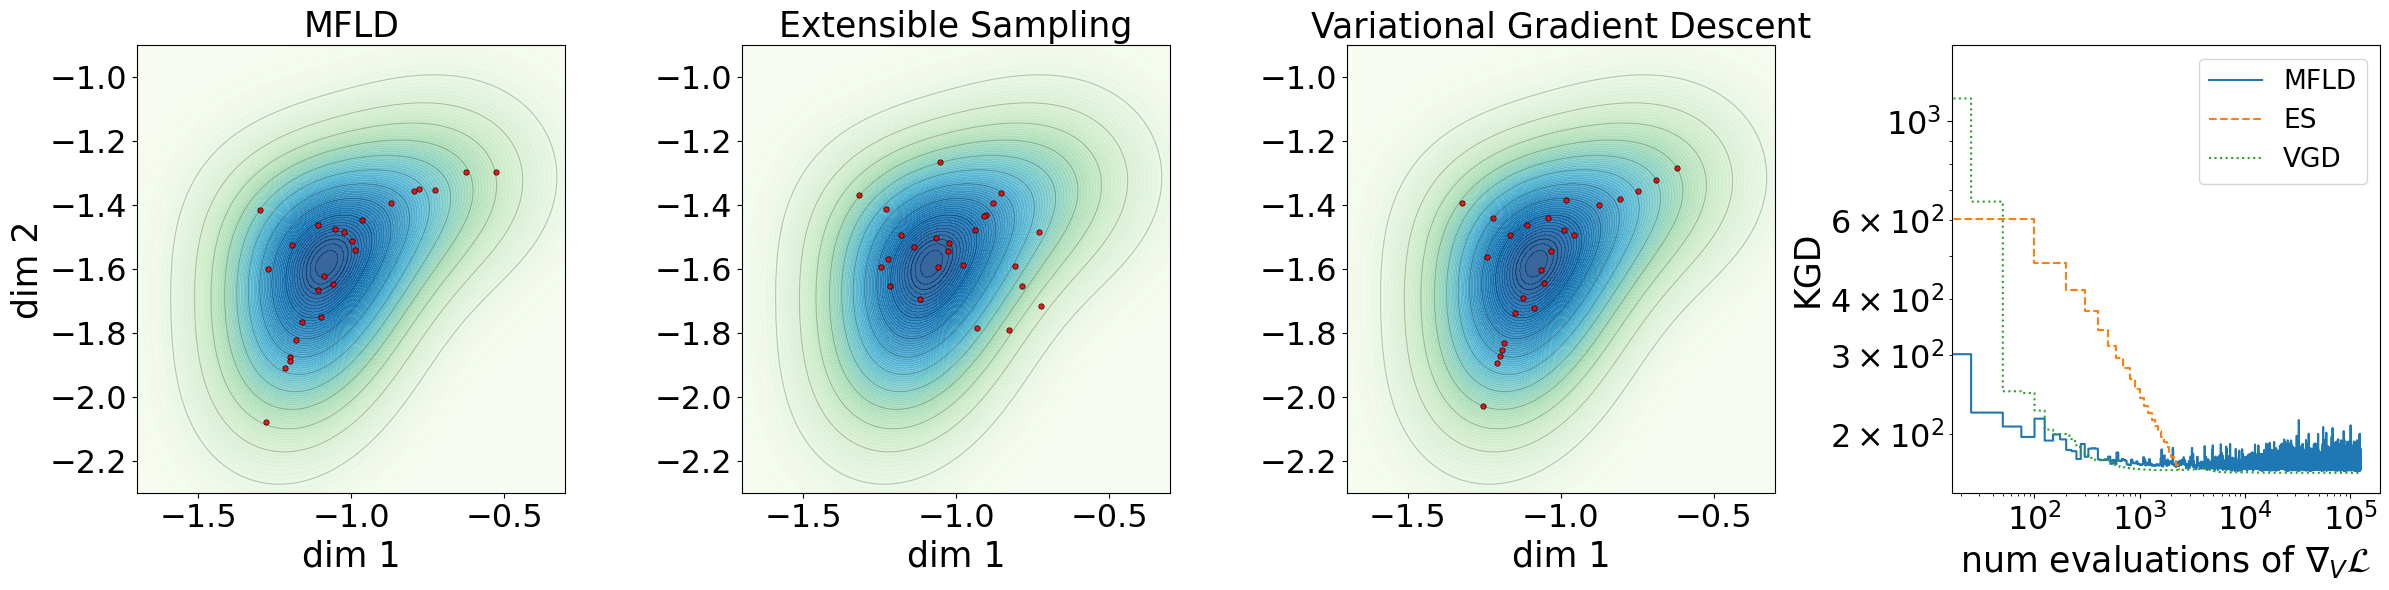

In [38]:
import jax.numpy as jnp
import matplotlib.pyplot as plt

x = jnp.linspace(-1.7, -0.3, 200)
y = jnp.linspace(-2.3, -0.9, 200)
X, Y = jnp.meshgrid(x, y)
Z = jnp.array([[kde_mfld(jnp.array([x, y])) for x in x] for y in y])

plt.rcParams.update({
    'axes.titlesize': 25,        # Taille des titres des axes
    'axes.labelsize': 25,        # Taille des labels des axes
    'xtick.labelsize': 23,       # Taille des ticks sur l'axe x
    'ytick.labelsize': 23,       # Taille des ticks sur l'axe y
    'legend.fontsize': 19,       # Taille de la légende
    'figure.titlesize': 25       # Taille du titre global (si utilisé)
})

#plt.style.use('default')
fig, axes = plt.subplots(1, 4, figsize=(16*1.5, 4*1.5))

for ind, expe in enumerate(list(expe3_results_loaded.keys())[1:]):
    
    # Fond dégradé avec transparence
    cf = axes[ind].contourf(
        X, Y, Z, 
        levels=100,          # plus de niveaux pour un dégradé lisse
        cmap='GnBu', 
        alpha=0.8     # transparence du fond
    )
    
    # Lignes de contour par-dessus
    axes[ind].contour(
        X, Y, Z, 
        levels=10, 
        colors='black', 
        linewidths=0.8,
        alpha=0.2
    )
    
    # Points très contrastés
    axes[ind].scatter(
        expe3_results_loaded[expe]["X_fin"][:, 0],
        expe3_results_loaded[expe]["X_fin"][:, 1],
        label="final particles",
        c='red',
        edgecolor='black',
        linewidth=0.5,
        s=15,
        alpha=0.9
    )
    
    axes[ind].set_title(expe)
    axes[ind].set_xlabel('dim 1')
    axes[ind].set_ylabel('dim 2')
    #axes[ind].legend()
axes[1].set_ylabel("")
axes[2].set_ylabel("")

tab_ODE_solved = 10**2 * jnp.arange(0,5000) #25
axes[3].set_facecolor('white')

axes[3].step(expe3_results_loaded["MFLD"]["gradL_eval"],
    expe3_results_loaded["MFLD"]["KGD_values"], 
    label="MFLD", 
    linestyle='-'
)
axes[3].step(expe3_results_loaded["Extensible Sampling"]["gradL_eval"],
    expe3_results_loaded["Extensible Sampling"]["KGD_values"], 
    label="ES", 
    linestyle='--'
)
axes[3].step(expe3_results_loaded["Variational Gradient Descent"]["gradL_eval"],
    expe3_results_loaded["Variational Gradient Descent"]["KGD_values"], 
    label="VGD", 
    linestyle=':'
)
axes[3].legend()
axes[3].set_xscale("log")
axes[3].set_yscale("log")
axes[3].set_xlabel(r"num evaluations of $\nabla_V \mathcal{L}$")
axes[3].set_ylabel("KGD")
#plt.title("KGD")
plt.tight_layout()

#plt.savefig("fig3.png", format="png")


plt.show()